# cd_A: is_in_markov_equic_class 与 score / cpdag_shd 关系实验

- 固定实验：`d=5, e=4, |v|=2`
- 算法：`cd_A`（epoch 版本）
- 重复次数：100
- 统计字段：`score`, `is_in_markov_equic_class`, `cpdag_shd`, `true_score`
- 分析：
  1. `is_in_markov_equic_class=True/False` 的 `score` 是否有显著差异
  2. `cpdag_shd` 与 `score` 的关系
  3. 可视化中加入 `true_score` 作为基准线

In [10]:
import os
import sys
import time
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.stats import ttest_ind, mannwhitneyu, spearmanr
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

CURRENT_DIR = os.getcwd()
if os.path.exists(os.path.join(CURRENT_DIR, 'synthetic_dataset.py')):
    REPO_ROOT = CURRENT_DIR
elif os.path.basename(CURRENT_DIR) == 'experiments' and os.path.exists(os.path.join(CURRENT_DIR, '..', 'synthetic_dataset.py')):
    REPO_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, '..'))
else:
    REPO_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, '..'))

if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

from SCM_data import generate_scm_from_BN
from synthetic_dataset import SyntheticDataset
from MEC import is_in_markov_equiv_class
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0_epoch as cd_A
from coordinate_descent.coordinate0 import f as cd_A_objective

try:
    toolbox_path = os.path.join(REPO_ROOT, 'toolbox')
    if toolbox_path not in sys.path:
        sys.path.append(toolbox_path)
    from cdt.metrics import SHD_CPDAG as cdt_shd_cpdag
except Exception:
    cdt_shd_cpdag = None

print('REPO_ROOT =', REPO_ROOT)
print('HAS_SCIPY =', HAS_SCIPY)
print('HAS_CDT_CPDAG =', cdt_shd_cpdag is not None)

REPO_ROOT = c:\Users\super\DAG
HAS_SCIPY = True
HAS_CDT_CPDAG = True


In [11]:
# 实验配置（对应 Experiment 9）
EXP = {
    'name': 'd=5, e=4, |v|=2',
    'B_true': np.array([
        [0, 0, 0, 1, 0],
        [0, 0, 0, 2, 3],
        [0, 0, 0, 0, 4],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
    ], dtype=float),
    'N': np.array([1, 2, 3, 2, 1], dtype=float),
}

CFG = {
    'n_samples': 5000,
    'n_repeats': 200,
    'base_seed': 10,
    'threshold': 0.05,
    'epochs_a': 1000,
    'lambda_l0': 0.0,
    'tol': 1e-4,
    'patience': 10,
    'min_epochs': 50,
}

def weight_to_binary_adj(W: np.ndarray, threshold: float = 0.05) -> np.ndarray:
    G = (np.abs(W) > threshold).astype(int)
    np.fill_diagonal(G, 0)
    return G

def get_skeleton(G: np.ndarray) -> np.ndarray:
    G_bin = (G > 0).astype(int)
    return ((G_bin + G_bin.T) > 0).astype(int)

def find_v_structures(G: np.ndarray):
    G_bin = (G > 0).astype(int)
    p = G_bin.shape[0]
    v_structures = set()
    for i in range(p):
        for j in range(p):
            for k in range(p):
                if i == j or j == k or i == k:
                    continue
                if G_bin[i, j] == 1 and G_bin[k, j] == 1 and G_bin[i, k] == 0 and G_bin[k, i] == 0:
                    v_structures.add(tuple(sorted([i, k])) + (j,))
    return v_structures

def cpdag_shd_score(G_true: np.ndarray, G_est: np.ndarray) -> float:
    if cdt_shd_cpdag is not None:
        try:
            return float(cdt_shd_cpdag(G_true.astype(int), G_est.astype(int)))
        except Exception:
            pass

    skel_true = get_skeleton(G_true)
    skel_est = get_skeleton(G_est)
    skeleton_diff = int(np.sum(np.abs(skel_true - skel_est)) // 2)

    v_true = find_v_structures(G_true)
    v_est = find_v_structures(G_est)
    v_diff = len(v_true.symmetric_difference(v_est))

    return float(skeleton_diff + v_diff)

B_true = EXP['B_true']
N = EXP['N']
d = B_true.shape[0]
Omega_true = np.diag(N)
A_true = (np.eye(d) - B_true) @ np.diag(1.0 / np.sqrt(N))
G_true = weight_to_binary_adj(B_true, threshold=0.0)

print('Experiment:', EXP['name'])
print('d =', d, '| repeats =', CFG['n_repeats'])

Experiment: d=5, e=4, |v|=2
d = 5 | repeats = 200


In [12]:
# 100 次实验
rows: List[Dict[str, float]] = []

for repeat_id in range(CFG['n_repeats']):
    seed = int(CFG['base_seed'] + repeat_id)

    data, _, _, _ = generate_scm_from_BN(
        B_true.T,
        n_samples=CFG['n_samples'],
        N=N,
        seed=seed,
    )

    S = data.T @ data / data.shape[0]

    t0 = time.perf_counter()
    A_est, G_est, score_end, history = cd_A(
        S=S,
        n_epochs=CFG['epochs_a'],
        seed=seed,
        threshold=CFG['threshold'],
        lambda_l0=CFG['lambda_l0'],
        tol=CFG['tol'],
        patience=CFG['patience'],
        min_epochs=CFG['min_epochs'],
        verbose=False,
    )
    t1 = time.perf_counter()

    is_mec = bool(is_in_markov_equiv_class(G_true, G_est))
    cpdag_shd = cpdag_shd_score(G_true, G_est)
    true_score = float(cd_A_objective(A_true, S))

    rows.append({
        'repeat_id': int(repeat_id),
        'seed': seed,
        'score': float(score_end),
        'true_score': true_score,
        'score_minus_true': float(score_end - true_score),
        'is_in_markov_equic_class': bool(is_mec),
        'is_in_markov_equiv_class': bool(is_mec),
        'cpdag_shd': float(cpdag_shd),
        'runtime_sec': float(t1 - t0),
        'n_epochs_run': int(len(history)),
    })

df_trials = pd.DataFrame(rows)
print(df_trials.head())
print('\nTotal rows:', len(df_trials))

   repeat_id  seed     score  true_score  score_minus_true  \
0          0    10  7.544470    7.548008         -0.003538   
1          1    11  7.467802    7.472417         -0.004615   
2          2    12  7.505153    7.506075         -0.000921   
3          3    13  7.531786    7.534199         -0.002413   
4          4    14  7.474047    7.474664         -0.000617   

   is_in_markov_equic_class  is_in_markov_equiv_class  cpdag_shd  runtime_sec  \
0                      True                      True        0.0     0.501328   
1                      True                      True        0.0     0.557168   
2                      True                      True        0.0     0.585899   
3                     False                     False        1.0     0.560154   
4                      True                      True        0.0     0.560708   

   n_epochs_run  
0            59  
1            59  
2            59  
3            59  
4            59  

Total rows: 200


In [13]:
# 统计：MEC True/False 时 score 是否有显著偏差
summary = (
    df_trials.groupby('is_in_markov_equic_class', as_index=False)
    .agg(
        n=('score', 'size'),
        score_mean=('score', 'mean'),
        score_std=('score', 'std'),
        score_median=('score', 'median'),
        true_score_mean=('true_score', 'mean'),
        score_minus_true_mean=('score_minus_true', 'mean'),
        cpdag_shd_mean=('cpdag_shd', 'mean'),
    )
)
display(summary)

score_true_group = df_trials.loc[df_trials['is_in_markov_equic_class'] == True, 'score'].to_numpy()
score_false_group = df_trials.loc[df_trials['is_in_markov_equic_class'] == False, 'score'].to_numpy()

print('score(True) n =', len(score_true_group), '| score(False) n =', len(score_false_group))

if len(score_true_group) >= 2 and len(score_false_group) >= 2 and HAS_SCIPY:
    t_stat, p_t = ttest_ind(score_true_group, score_false_group, equal_var=False, nan_policy='omit')
    u_stat, p_u = mannwhitneyu(score_true_group, score_false_group, alternative='two-sided')

    mean_diff = float(np.mean(score_true_group) - np.mean(score_false_group))
    s1 = np.var(score_true_group, ddof=1)
    s2 = np.var(score_false_group, ddof=1)
    pooled_sd = np.sqrt(((len(score_true_group) - 1) * s1 + (len(score_false_group) - 1) * s2) / (len(score_true_group) + len(score_false_group) - 2))
    cohen_d = mean_diff / pooled_sd if pooled_sd > 0 else np.nan

    print(f"Welch t-test: t={t_stat:.4f}, p={p_t:.4g}")
    print(f"Mann-Whitney U: U={u_stat:.4f}, p={p_u:.4g}")
    print(f"Mean difference (True - False): {mean_diff:.6f}")
    print(f"Cohen's d: {cohen_d:.6f}")
else:
    print('样本不足或 scipy 不可用，无法进行显著性检验。')

,is_in_markov_equic_class,n,score_mean,score_std,score_median,true_score_mean,score_minus_true_mean,cpdag_shd_mean
0,False,42,7.476018,0.047780,7.477249,7.475399,0.000619,1.47619
1,True,158,7.480900,0.047986,7.481438,7.482956,-0.002056,0.00000


score(True) n = 158 | score(False) n = 42
Welch t-test: t=0.5880, p=0.5585
Mann-Whitney U: U=3450.0000, p=0.6933
Mean difference (True - False): 0.004882
Cohen's d: 0.101833


The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
Glyph 31561 (\N{CJK UNIFIED IDEOGRAPH-7B49}) missing from font(s) DejaVu Sans.
Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
Glyph 21305 (\N{CJK UNIFIED IDEOGRAPH-5339}) missing from font(s) DejaVu Sans.
Glyph 37197 (\N{CJK UNIFIED IDEOGRAPH-914D}) missing from font(s) DejaVu Sans.
Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
Glyph 31561 (\N{CJK UNIFIED IDEOGRAPH-7B49}) missing from font(s) DejaVu Sans.
Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaV

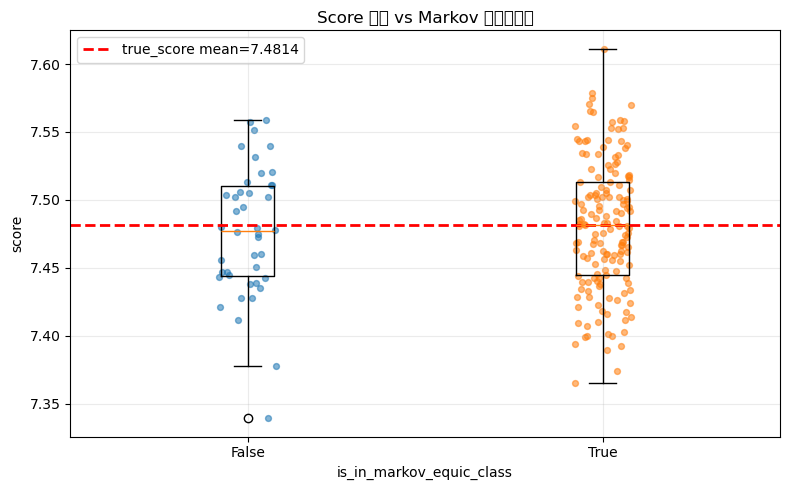

In [14]:
# 可视化 1：按 is_in_markov_equic_class 分组的 score 分布（含 true_score 基准）
fig, ax = plt.subplots(figsize=(8, 5))

x_labels = [False, True]
data_for_box = [
    df_trials.loc[df_trials['is_in_markov_equic_class'] == lab, 'score'].to_numpy()
    for lab in x_labels
]

ax.boxplot(data_for_box, labels=[str(x) for x in x_labels], showfliers=True)

rng = np.random.default_rng(0)
for i, lab in enumerate(x_labels, start=1):
    y = df_trials.loc[df_trials['is_in_markov_equic_class'] == lab, 'score'].to_numpy()
    x = i + rng.uniform(-0.08, 0.08, size=len(y))
    ax.scatter(x, y, s=18, alpha=0.55)

true_score_mean = float(df_trials['true_score'].mean())
ax.axhline(true_score_mean, color='red', linestyle='--', linewidth=2, label=f'true_score mean={true_score_mean:.4f}')

ax.set_xlabel('is_in_markov_equic_class')
ax.set_ylabel('score')
ax.set_title('Score 分布 vs Markov 等价类匹配')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.


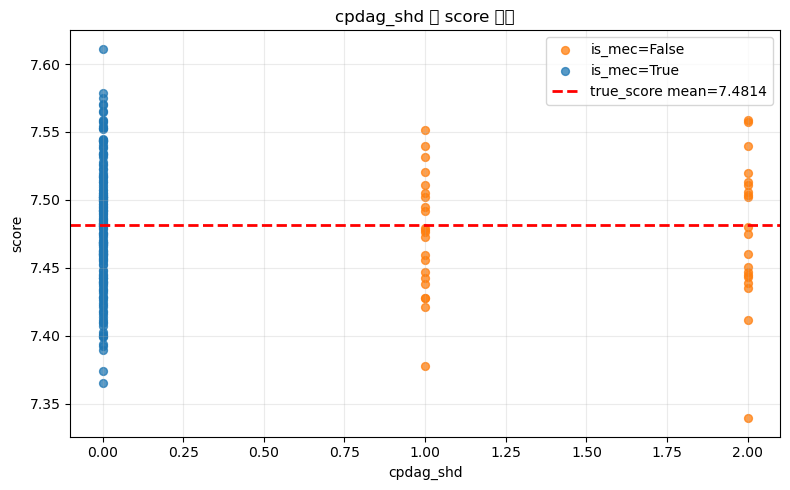

Spearman correlation(score, cpdag_shd): rho=-0.0253, p=0.7221


In [15]:
# 可视化 2：cpdag_shd 与 score 的关系（含 true_score 基准）
fig, ax = plt.subplots(figsize=(8, 5))

for label, color in [(False, 'tab:orange'), (True, 'tab:blue')]:
    sub = df_trials[df_trials['is_in_markov_equic_class'] == label]
    ax.scatter(sub['cpdag_shd'], sub['score'], alpha=0.75, s=32, c=color, label=f'is_mec={label}')

true_score_mean = float(df_trials['true_score'].mean())
ax.axhline(true_score_mean, color='red', linestyle='--', linewidth=2, label=f'true_score mean={true_score_mean:.4f}')

ax.set_xlabel('cpdag_shd')
ax.set_ylabel('score')
ax.set_title('cpdag_shd 与 score 关系')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

if HAS_SCIPY:
    rho, p_rho = spearmanr(df_trials['cpdag_shd'], df_trials['score'], nan_policy='omit')
    print(f'Spearman correlation(score, cpdag_shd): rho={rho:.4f}, p={p_rho:.4g}')

In [ ]:
# 随机 ER 图：进行相同实验（score / is_in_markov_equic_class / cpdag_shd）
# 说明：先固定一张随机 ER 真图，再重复采样 100(或 CFG['n_repeats']) 次数据评估 cd_A。

ER_CFG = {
    'd': 10,
    'degree': 2.0,
    'noise_type': 'gaussian_nv',
    'b_scale': 5.0,
    'graph_seed': 20260301,
    'n_repeats': CFG['n_repeats'],
    'n_samples': CFG['n_samples'],
    'base_seed': CFG['base_seed'],
}

# 1) 固定随机 ER 真图（B_true_er）和噪声尺度（N_er）
er_base = SyntheticDataset(
    n=ER_CFG['n_samples'],
    d=ER_CFG['d'],
    graph_type='ER',
    degree=ER_CFG['degree'],
    noise_type=ER_CFG['noise_type'],
    B_scale=ER_CFG['b_scale'],
    seed=ER_CFG['graph_seed'],
)

B_true_er = np.array(er_base.B, dtype=float)
N_er = np.array(er_base.N, dtype=float)
d_er = B_true_er.shape[0]

A_true_er = (np.eye(d_er) - B_true_er) @ np.diag(1.0 / np.sqrt(N_er))
G_true_er = weight_to_binary_adj(B_true_er, threshold=0.0)

print('ER fixed graph config:', ER_CFG)
print('ER true edge count   :', int(np.sum(np.abs(B_true_er) > 0)))

# 2) 重复实验
rows_er: List[Dict[str, float]] = []
for repeat_id in range(ER_CFG['n_repeats']):
    seed = int(ER_CFG['base_seed'] + repeat_id)

    data_er, _, _, _ = generate_scm_from_BN(
        B_true_er.T,
        n_samples=ER_CFG['n_samples'],
        N=N_er,
        seed=seed,
    )
    S_er = data_er.T @ data_er / data_er.shape[0]

    t0 = time.perf_counter()
    A_est_er, G_est_er, score_end_er, history_er = cd_A(
        S=S_er,
        n_epochs=CFG['epochs_a'],
        seed=seed,
        threshold=CFG['threshold'],
        lambda_l0=CFG['lambda_l0'],
        tol=CFG['tol'],
        patience=CFG['patience'],
        min_epochs=CFG['min_epochs'],
        verbose=False,
    )
    t1 = time.perf_counter()

    is_mec_er = bool(is_in_markov_equiv_class(G_true_er, G_est_er))
    cpdag_shd_er = cpdag_shd_score(G_true_er, G_est_er)
    true_score_er = float(cd_A_objective(A_true_er, S_er))

    rows_er.append({
        'repeat_id': int(repeat_id),
        'seed': seed,
        'score': float(score_end_er),
        'true_score': true_score_er,
        'score_minus_true': float(score_end_er - true_score_er),
        'is_in_markov_equic_class': bool(is_mec_er),
        'is_in_markov_equiv_class': bool(is_mec_er),
        'cpdag_shd': float(cpdag_shd_er),
        'runtime_sec': float(t1 - t0),
        'n_epochs_run': int(len(history_er)),
    })

df_trials_er = pd.DataFrame(rows_er)
print(df_trials_er.head())
print('\nTotal ER rows:', len(df_trials_er))

# Mean score per cpdag_shd
mean_score_by_shd_er = (
    df_trials_er.groupby('cpdag_shd')['score']
    .agg(n='count', score_mean='mean', score_std='std')
    .reset_index()
)
print('\nMean score per cpdag_shd:')
print(mean_score_by_shd_er.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

# 3) 统计与显著性检验
summary_er = (
    df_trials_er.groupby('is_in_markov_equic_class', as_index=False)
    .agg(
        n=('score', 'size'),
        score_mean=('score', 'mean'),
        score_std=('score', 'std'),
        score_median=('score', 'median'),
        true_score_mean=('true_score', 'mean'),
        score_minus_true_mean=('score_minus_true', 'mean'),
        cpdag_shd_mean=('cpdag_shd', 'mean'),
    )
)
display(summary_er)

score_true_group_er = df_trials_er.loc[df_trials_er['is_in_markov_equic_class'] == True, 'score'].to_numpy()
score_false_group_er = df_trials_er.loc[df_trials_er['is_in_markov_equic_class'] == False, 'score'].to_numpy()

print('ER score(True) n =', len(score_true_group_er), '| score(False) n =', len(score_false_group_er))
if len(score_true_group_er) >= 2 and len(score_false_group_er) >= 2 and HAS_SCIPY:
    t_stat_er, p_t_er = ttest_ind(score_true_group_er, score_false_group_er, equal_var=False, nan_policy='omit')
    u_stat_er, p_u_er = mannwhitneyu(score_true_group_er, score_false_group_er, alternative='two-sided')

    mean_diff_er = float(np.mean(score_true_group_er) - np.mean(score_false_group_er))
    s1_er = np.var(score_true_group_er, ddof=1)
    s2_er = np.var(score_false_group_er, ddof=1)
    pooled_sd_er = np.sqrt(((len(score_true_group_er) - 1) * s1_er + (len(score_false_group_er) - 1) * s2_er) / (len(score_true_group_er) + len(score_false_group_er) - 2))
    cohen_d_er = mean_diff_er / pooled_sd_er if pooled_sd_er > 0 else np.nan

    print(f"ER Welch t-test: t={t_stat_er:.4f}, p={p_t_er:.4g}")
    print(f"ER Mann-Whitney U: U={u_stat_er:.4f}, p={p_u_er:.4g}")
    print(f"ER Mean difference (True - False): {mean_diff_er:.6f}")
    print(f"ER Cohen's d: {cohen_d_er:.6f}")
else:
    print('ER: 样本不足或 scipy 不可用，无法进行显著性检验。')

# 4) 可视化 1：按 is_in_markov_equic_class 分组的 score 分布（含 true_score 基准）
fig, ax = plt.subplots(figsize=(8, 5))
x_labels_er = [False, True]
data_for_box_er = [
    df_trials_er.loc[df_trials_er['is_in_markov_equic_class'] == lab, 'score'].to_numpy()
    for lab in x_labels_er
]
ax.boxplot(data_for_box_er, labels=[str(x) for x in x_labels_er], showfliers=True)

rng_er = np.random.default_rng(0)
for i, lab in enumerate(x_labels_er, start=1):
    y = df_trials_er.loc[df_trials_er['is_in_markov_equic_class'] == lab, 'score'].to_numpy()
    x = i + rng_er.uniform(-0.08, 0.08, size=len(y))
    ax.scatter(x, y, s=18, alpha=0.55)

true_score_mean_er = float(df_trials_er['true_score'].mean())
ax.axhline(true_score_mean_er, color='red', linestyle='--', linewidth=2, label=f'true_score mean={true_score_mean_er:.4f}')
ax.set_xlabel('is_in_markov_equic_class')
ax.set_ylabel('score')
ax.set_title('ER graph: Score 分布 vs Markov 等价类匹配')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 5) 可视化 2：cpdag_shd 与 score 的关系（含 true_score 基准 + 每个 SHD 的均值）
fig, ax = plt.subplots(figsize=(8, 5))
for label, color in [(False, 'tab:orange'), (True, 'tab:blue')]:
    sub = df_trials_er[df_trials_er['is_in_markov_equic_class'] == label]
    ax.scatter(sub['cpdag_shd'], sub['score'], alpha=0.55, s=28, c=color, label=f'is_mec={label}')

# Mean score per SHD — overlay as connected line with error bars
shd_vals = mean_score_by_shd_er['cpdag_shd'].to_numpy()
shd_means = mean_score_by_shd_er['score_mean'].to_numpy()
shd_stds  = mean_score_by_shd_er['score_std'].fillna(0).to_numpy()
ax.errorbar(
    shd_vals, shd_means, yerr=shd_stds,
    color='black', marker='D', markersize=7, linewidth=1.8,
    capsize=4, zorder=5, label='mean score per SHD',
)

ax.axhline(true_score_mean_er, color='red', linestyle='--', linewidth=2, label=f'true_score mean={true_score_mean_er:.4f}')
ax.set_xlabel('cpdag_shd')
ax.set_ylabel('score')
ax.set_title('ER graph: cpdag_shd 与 score 关系')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

if HAS_SCIPY:
    rho_er, p_rho_er = spearmanr(df_trials_er['cpdag_shd'], df_trials_er['score'], nan_policy='omit')
    print(f'ER Spearman correlation(score, cpdag_shd): rho={rho_er:.4f}, p={p_rho_er:.4g}')


ER fixed graph config: {'d': 10, 'degree': 2.0, 'noise_type': 'gaussian_nv', 'b_scale': 5.0, 'graph_seed': 20260301, 'n_repeats': 200, 'n_samples': 5000, 'base_seed': 10}
ER true edge count   : 11


In [17]:
# 保存结果（可选）
out_dir = os.path.join(REPO_ROOT, 'experiments', 'results')
os.makedirs(out_dir, exist_ok=True)

trial_csv = os.path.join(out_dir, 'cd_A_mec_score_relation_exp9_trials.csv')
summary_csv = os.path.join(out_dir, 'cd_A_mec_score_relation_exp9_summary_by_mec.csv')

df_trials.to_csv(trial_csv, index=False, encoding='utf-8-sig')
summary.to_csv(summary_csv, index=False, encoding='utf-8-sig')

print('Saved:')
print(' -', trial_csv)
print(' -', summary_csv)

Saved:
 - c:\Users\super\DAG\experiments\results\cd_A_mec_score_relation_exp9_trials.csv
 - c:\Users\super\DAG\experiments\results\cd_A_mec_score_relation_exp9_summary_by_mec.csv


Loaded 200 rows from cd_A_mec_score_relation_exp9_trials.csv

Mean score per cpdag_shd:
 cpdag_shd   n  score_mean  score_std
  0.000000 158    7.480900   0.047986
  1.000000  22    7.475178   0.043390
  2.000000  20    7.476941   0.053327


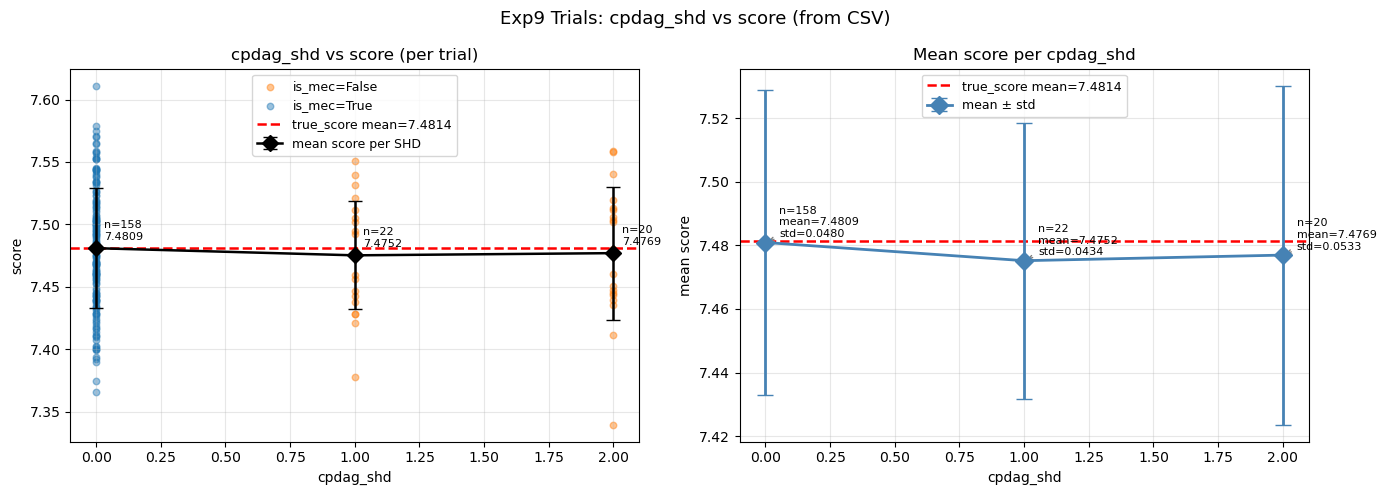

In [21]:
# 从 trials CSV 可视化 cpdag_shd 与 score 的关系
csv_path = os.path.join(REPO_ROOT, 'experiments', 'results',
                        'cd_A_mec_score_relation_exp9_trials.csv')
df_csv = pd.read_csv(csv_path)
print(f'Loaded {len(df_csv)} rows from {os.path.basename(csv_path)}')

# Mean score per cpdag_shd
mean_by_shd = (
    df_csv.groupby('cpdag_shd')['score']
    .agg(n='count', score_mean='mean', score_std='std')
    .reset_index()
)
print('\nMean score per cpdag_shd:')
print(mean_by_shd.to_string(index=False, float_format=lambda v: f'{v:.6f}'))

true_score_ref = float(df_csv['true_score'].mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 左图：散点 + 均值折线 ---
ax0 = axes[0]
for is_mec, color in [(False, 'tab:orange'), (True, 'tab:blue')]:
    sub = df_csv[df_csv['is_in_markov_equic_class'] == is_mec]
    ax0.scatter(sub['cpdag_shd'], sub['score'],
                alpha=0.45, s=22, c=color, label=f'is_mec={is_mec}')

shd_x    = mean_by_shd['cpdag_shd'].to_numpy()
shd_mean = mean_by_shd['score_mean'].to_numpy()
shd_std  = mean_by_shd['score_std'].fillna(0).to_numpy()
ax0.errorbar(shd_x, shd_mean, yerr=shd_std,
             color='black', marker='D', markersize=8, linewidth=1.8,
             capsize=5, zorder=5, label='mean score per SHD')
for xv, mv, nv in zip(shd_x, shd_mean, mean_by_shd['n']):
    ax0.annotate(f'n={nv}\n{mv:.4f}', xy=(xv, mv),
                 xytext=(6, 6), textcoords='offset points', fontsize=8)

ax0.axhline(true_score_ref, color='red', linestyle='--', linewidth=1.8,
            label=f'true_score mean={true_score_ref:.4f}')
ax0.set_xlabel('cpdag_shd')
ax0.set_ylabel('score')
ax0.set_title('cpdag_shd vs score (per trial)')
ax0.legend(fontsize=9)
ax0.grid(alpha=0.3)

# --- 右图：均值折线单独展示（更清晰） ---
ax1 = axes[1]
ax1.errorbar(shd_x, shd_mean, yerr=shd_std,
             color='steelblue', marker='D', markersize=9, linewidth=2,
             capsize=6, zorder=5, label='mean ± std')
for xv, mv, sv, nv in zip(shd_x, shd_mean, shd_std, mean_by_shd['n']):
    ax1.annotate(f'n={nv}\nmean={mv:.4f}\nstd={sv:.4f}',
                 xy=(xv, mv), xytext=(10, 4),
                 textcoords='offset points', fontsize=8,
                 arrowprops=dict(arrowstyle='->', color='gray'))
ax1.axhline(true_score_ref, color='red', linestyle='--', linewidth=1.8,
            label=f'true_score mean={true_score_ref:.4f}')
ax1.set_xlabel('cpdag_shd')
ax1.set_ylabel('mean score')
ax1.set_title('Mean score per cpdag_shd')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

fig.suptitle('Exp9 Trials: cpdag_shd vs score (from CSV)', fontsize=13)
plt.tight_layout()
plt.show()
